##José Alberto Isidoro Sánchez

# **FINAL PROJECT CNNs for Fashion Mnist dataset**
The project is divided in 3 parts

** Part 1: Normal Neural Network manually with different optimizers**
* Layer 1 (Hidden Layer): Uses a Linear transformation followed by a ReLU activation function.

* Layer 2 (Hidden Layer): Also uses a Linear transformation followed by a ReLU activation function.

* Layer 3 (Output Layer): Uses a Linear transformation followed by a Softmax activation function to classify the 10 fashion categories.



---



- Part 2: CNN optimized with grid search
- Part 3: CNN optimized with Keras and Tensorflow

(separated in 3 pdfs)

## **FINAL PROJECT PT 1**

#### FASHION MNIST DATASET: GRID SEARCH VS KERAS TUNNER | FINAL PROJECT

Objetivo

Entrenar un modelo de clasificacion usando el dataset Fashion MNIST utilizando todos los conceptos aprendidos en clase
Instrucciones

El equipo debe desarollar un modelo de clasificacion (ya sea custom o un modelo ya existente) y entrenardo para obtener el mejor rendimiento posible en estos datos

    - Se espera que utilicen todos los aspectos aprendidos en clase: regularización, optimización, hyper-parameter tuning, etc. Se pueden probar diferentes modelos de CNNs o definir la suya propia o hacer una comparativa entre modelos.
    - Una vez realizados los experimentos, el equipo deberá realizar una presentación de 15 minutos detallando todos los experimentos, pruebas y los resultados obtenidos. Por favor limitar la cantidad de texto, usar y mantenerla lo más gráfica posible
    - La presentación deberá contener algún tipo de  demo y demostraciones del método, la calidad de los medios de soporte será evaluada (estos pueden ser videos encontrados en internet o codigo que el equipo eche a andar.
    - Todos los miembros del equipo deben presentar y ser capaces de responder a las preguntas del profesor y sus compañeros.


Especificaciones de entrega

    - Modalidad: Equipo.
    - Medio de realización/entrega: La presentación se hará durante la clase y el envío de la presentación se hará a en PDF.
    - Formato: Presentación de 10 mins más 5 mins de demo, el envío se realizará en formato PDF.


Criterios de evaluación

    - Presentación:  55%
    - Calidad de la investigación bibliográfica:  20%
    - Recursos visuales y diseño:  10%
    - Dominio técnico y respuestas: 15%

#DATASET
Fashion MNIST
An MNIST-like dataset of 70,000 28x28 labeled fashion images

https://www.kaggle.com/datasets/zalando-research/fashionmnist


#Fashion MNIST INDEX:
| Índice	| Etiqueta (Clase)|
|---|---|
|0	| T-shirt/top (Camiseta)|
|1	| Trouser (Pantalón)|
|2	| Pullover (Suéter)|
|3	| Dress (Vestido)|
|4	| Coat (Abrigo)|
|5	| Sandal (Sandalia)|
|6	| Shirt (Camisa)|
|7	| Sneaker (Zapatilla deportiva)|
|8	| Bag (Bolso)|
|9	| Ankle boot (Botín/Bota)|

In [ ]:
!pip install tensorflow

#MANUAL MODEL:

In [ ]:
##NEW VERSION
# ============================================
# IMPORTS AND SETUP
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
import math
import time




# Set random seed for reproducibility
np.random.seed(42)

# Fashion-MNIST labels
fashion_labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                  'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Setup complete")

# ============================================
# DATA LOADING AND PREPROCESSING
# ============================================
def load_and_preprocess_fashion_mnist():
    """Load and preprocess Fashion-MNIST dataset"""
    # Load data
    (X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

    # Print original shapes
    print(f"Original X_train shape: {X_train.shape}")
    print(f"Original y_train shape: {y_train.shape}")

    # Store original images for visualization
    X_train_original = X_train.copy()
    X_test_original = X_test.copy()

    # Flatten images: 28x28 = 784 features
    X_train = X_train.reshape(X_train.shape[0], -1).T  # (784, 60000)
    X_test = X_test.reshape(X_test.shape[0], -1).T    # (784, 10000)

    # Normalize to [0, 1]
    X_train = X_train / 255.0
    X_test = X_test / 255.0

    # One-hot encode labels (10 classes)
    y_train_onehot = np.zeros((10, y_train.shape[0]))
    y_test_onehot = np.zeros((10, y_test.shape[0]))

    for i in range(y_train.shape[0]):
        y_train_onehot[y_train[i], i] = 1
    for i in range(y_test.shape[0]):
        y_test_onehot[y_test[i], i] = 1

    print(f"\nProcessed X_train shape: {X_train.shape}")
    print(f"Processed y_train shape: {y_train_onehot.shape}")
    print("USING FULL DATASET")

    return X_train, y_train_onehot, X_test, y_test_onehot, y_train, y_test, X_train_original, X_test_original

# ============================================
# SUBSET LOADING AND PREPROCESSING
# ============================================
def load_and_preprocess_fashion_mnist_subset():
    """Load and preprocess Fashion-MNIST dataset"""
    # Load data
    (X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


    # Print original shapes
    print(f"Original X_train shape: {X_train.shape}")
    print(f"Original y_train shape: {y_train.shape}")

    #***************************************************
    # Store original images for visualization
    X_train_original = X_train.copy()
    X_test_original = X_test.copy()
    #***************************************************

    # Take subset for faster training (optional - remove for full training)
    # Using 20% of data for quicker testing
    n_train = X_train.shape[0]
    indices = np.random.choice(n_train, n_train // 5, replace=False)
    X_train = X_train[indices]
    y_train = y_train[indices]

    print(f"\nUsing subset: {X_train.shape[0]} training samples")

    # Flatten images: 28x28 = 784 features
    X_train = X_train.reshape(X_train.shape[0], -1).T  # (784, n_samples)
    X_test = X_test.reshape(X_test.shape[0], -1).T    # (784, 10000)

    # Normalize to [0, 1]
    X_train = X_train / 255.0
    X_test = X_test / 255.0

    # One-hot encode labels (10 classes)
    y_train_onehot = np.zeros((10, y_train.shape[0]))
    y_test_onehot = np.zeros((10, y_test.shape[0]))

    for i in range(y_train.shape[0]):
        y_train_onehot[y_train[i], i] = 1
    for i in range(y_test.shape[0]):
        y_test_onehot[y_test[i], i] = 1

    print(f"Processed X_train shape: {X_train.shape}")
    print(f"Processed y_train shape: {y_train_onehot.shape}")
    print("USING 20% SUBSET DATASET")
    return X_train, y_train_onehot, X_test, y_test_onehot, y_train, y_test, X_train_original, X_test_original



Setup complete


In [ ]:
# ============================================
# ACTIVATION FUNCTIONS
# ============================================
"""
def sigmoid(x):
    #Sigmoid activation function
    x = np.clip(x, -500, 500)  # Prevent overflow
    return 1 / (1 + np.exp(-x))
"""
def relu(x):
    """ReLU activation function"""
    return np.maximum(0, x)

def softmax(x):
    """Softmax activation function for multi-class classification"""
    # Subtract max for numerical stability
    shifted_x = x - np.max(x, axis=0, keepdims=True)
    exp_x = np.exp(shifted_x)
    return exp_x / np.sum(exp_x, axis=0, keepdims=True)

# ============================================
# COST FUNCTION (Categorical Cross-Entropy)
# ============================================
def compute_cost(aL, Y):
    """
    Compute categorical cross-entropy cost
    aL: output of last layer (softmax), shape (10, m)
    Y: true labels (one-hot), shape (10, m)
    """
    m = Y.shape[1]
    # Add small epsilon to avoid log(0)
    aL = np.clip(aL, 1e-8, 1 - 1e-8)
    cost = -np.sum(Y * np.log(aL)) / m
    return cost





# ============================================
# FIXED FORWARD PROPAGATION with shape checks
# ============================================
def forward_propagation(X, parameters):
    """
    Forward propagation with shape validation
    """
    # Retrieve parameters
    W1 = parameters["W1"]  # Access parameters
    b1 = parameters["b1"]
    W2 = parameters["W2"]  # Access parameters
    b2 = parameters["b2"]
    W3 = parameters["W3"]  # Access parameters
    b3 = parameters["b3"]

    # Shape validation
    assert X.shape[0] == W1.shape[1], f"X shape {X.shape} doesn't match W1 shape {W1.shape}"

    # Layer 1: Linear -> ReLU
    z1 = np.dot(W1, X) + b1
    a1 = relu(z1)

    # Layer 2: Linear -> ReLU
    z2 = np.dot(W2, a1) + b2
    a2 = relu(z2)

    # Layer 3: Linear -> Softmax
    z3 = np.dot(W3, a2) + b3
    a3 = softmax(z3)

    # Validate softmax output
    assert np.allclose(np.sum(a3, axis=0), 1.0), "Softmax outputs don't sum to 1"

    # Store ONLY what's needed for backprop (ADDED NEW)
    cache = (z1, a1, z2, a2, z3, a3)
    return a3, cache
    #OLD VERSION
   # return a3, (z1, a1, z2, a2, z3, a3)

# ============================================
# FIXED BACKWARD PROPAGATION - Matches new cache format
# ============================================
#Backward propagation uses both cache and parameters

def backward_propagation(X, Y, cache, parameters):
    """
    Backward propagation for multi-class classification
    cache: (z1, a1, z2, a2, z3, a3) from forward_propagation
    parameters: dictionary containing W1, b1, W2, b2, W3, b3
    """
    m = X.shape[1]
    z1, a1, z2, a2, z3, a3 = cache

    # Retrieve weights from parameters
    W1 = parameters["W1"]
    W2 = parameters["W2"]
    W3 = parameters["W3"]

    # Layer 3 gradient (Softmax + Cross-entropy)
    dz3 = a3 - Y  # Simplified gradient for softmax + cross-entropy
    dW3 = np.dot(dz3, a2.T) / m
    db3 = np.sum(dz3, axis=1, keepdims=True) / m

    # Layer 2 gradient
    da2 = np.dot(W3.T, dz3)
    dz2 = np.multiply(da2, np.int64(a2 > 0))  # ReLU derivative
    dW2 = np.dot(dz2, a1.T) / m
    db2 = np.sum(dz2, axis=1, keepdims=True) / m

    # Layer 1 gradient
    da1 = np.dot(W2.T, dz2)
    dz1 = np.multiply(da1, np.int64(a1 > 0))  # ReLU derivative
    dW1 = np.dot(dz1, X.T) / m
    db1 = np.sum(dz1, axis=1, keepdims=True) / m

    gradients = {
        "dW1": dW1, "db1": db1,
        "dW2": dW2, "db2": db2,
        "dW3": dW3, "db3": db3
    }

    return gradients

# ============================================
# INITIALIZATION FUNCTIONS
# ============================================
def initialize_parameters(layer_dims):
    """
    Initialize parameters with He initialization
    layer_dims: list containing dimensions of each layer [n_x, n_h1, n_h2, n_y]
    """
    parameters = {}
    L = len(layer_dims)

    for l in range(1, L):
        # He initialization for ReLU layers
        parameters[f"W{l}"] = np.random.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(2. / layer_dims[l-1])
        parameters[f"b{l}"] = np.zeros((layer_dims[l], 1))

    return parameters

# ============================================
# OPTIMIZERS
# ============================================
def update_parameters_with_gd(parameters, grads, learning_rate):
    """Gradient Descent update"""
    L = len(parameters) // 2
    for l in range(1, L + 1):
        parameters[f"W{l}"] -= learning_rate * grads[f"dW{l}"]
        parameters[f"b{l}"] -= learning_rate * grads[f"db{l}"]
    return parameters

def initialize_velocity(parameters):
    """Initialize velocity for momentum"""
    L = len(parameters) // 2
    v = {}
    for l in range(1, L + 1):
        v[f"dW{l}"] = np.zeros_like(parameters[f"W{l}"])
        v[f"db{l}"] = np.zeros_like(parameters[f"b{l}"])
    return v

def update_parameters_with_momentum(parameters, grads, v, beta, learning_rate):
    """Momentum update"""
    L = len(parameters) // 2
    for l in range(1, L + 1):
        v[f"dW{l}"] = beta * v[f"dW{l}"] + (1 - beta) * grads[f"dW{l}"]
        v[f"db{l}"] = beta * v[f"db{l}"] + (1 - beta) * grads[f"db{l}"]
        parameters[f"W{l}"] -= learning_rate * v[f"dW{l}"]
        parameters[f"b{l}"] -= learning_rate * v[f"db{l}"]
    return parameters, v

def initialize_adam(parameters):
    """Initialize Adam optimizer"""
    L = len(parameters) // 2
    v = {}
    s = {}
    for l in range(1, L + 1):
        v[f"dW{l}"] = np.zeros_like(parameters[f"W{l}"])
        v[f"db{l}"] = np.zeros_like(parameters[f"b{l}"])
        s[f"dW{l}"] = np.zeros_like(parameters[f"W{l}"])
        s[f"db{l}"] = np.zeros_like(parameters[f"b{l}"])
    return v, s

def update_parameters_with_adam(parameters, grads, v, s, t, learning_rate, beta1=0.9, beta2=0.999, epsilon=1e-8):
    """Adam optimizer update"""
    L = len(parameters) // 2
    v_corrected = {}
    s_corrected = {}

    for l in range(1, L + 1):
        # Update biased first moment estimate
        v[f"dW{l}"] = beta1 * v[f"dW{l}"] + (1 - beta1) * grads[f"dW{l}"]
        v[f"db{l}"] = beta1 * v[f"db{l}"] + (1 - beta1) * grads[f"db{l}"]

        # Update biased second raw moment estimate
        s[f"dW{l}"] = beta2 * s[f"dW{l}"] + (1 - beta2) * (grads[f"dW{l}"] ** 2)
        s[f"db{l}"] = beta2 * s[f"db{l}"] + (1 - beta2) * (grads[f"db{l}"] ** 2)

        # Compute bias-corrected estimates
        v_corrected[f"dW{l}"] = v[f"dW{l}"] / (1 - beta1 ** t)
        v_corrected[f"db{l}"] = v[f"db{l}"] / (1 - beta1 ** t)
        s_corrected[f"dW{l}"] = s[f"dW{l}"] / (1 - beta2 ** t)
        s_corrected[f"db{l}"] = s[f"db{l}"] / (1 - beta2 ** t)

        # Update parameters
        parameters[f"W{l}"] -= learning_rate * v_corrected[f"dW{l}"] / (np.sqrt(s_corrected[f"dW{l}"]) + epsilon)
        parameters[f"b{l}"] -= learning_rate * v_corrected[f"db{l}"] / (np.sqrt(s_corrected[f"db{l}"]) + epsilon)

    return parameters, v, s

# ===========================================
# MINI-BATCH GENERATION
# =========================================
def random_mini_batches(X, Y, mini_batch_size=64, seed=0):
    """Create random mini-batches"""
    np.random.seed(seed)
    m = X.shape[1]
    mini_batches = []

    # Shuffle
    permutation = list(np.random.permutation(m))
    shuffled_X = X[:, permutation]
    shuffled_Y = Y[:, permutation]

    # Partition
    num_complete_minibatches = math.floor(m / mini_batch_size)
    for k in range(num_complete_minibatches):
        mini_batch_X = shuffled_X[:, k * mini_batch_size:(k + 1) * mini_batch_size]
        mini_batch_Y = shuffled_Y[:, k * mini_batch_size:(k + 1) * mini_batch_size]
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)

    # Handle last mini-batch
    if m % mini_batch_size != 0:
        mini_batch_X = shuffled_X[:, num_complete_minibatches * mini_batch_size:]
        mini_batch_Y = shuffled_Y[:, num_complete_minibatches * mini_batch_size:]
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)

    return mini_batches

# ============================================
# PREDICTION FUNCTION
# ============================================
def predict(X, Y, parameters):
    """Make predictions and calculate accuracy"""
    a3, _ = forward_propagation(X, parameters)
    predictions = np.argmax(a3, axis=0)
    true_labels = np.argmax(Y, axis=0)
    accuracy = np.mean(predictions == true_labels)
    return accuracy, predictions

# ============================================
# VISUALIZATION FUNCTION
# ============================================
def show_sample_predictions(parameters, X_test_original, y_test_raw, num_samples=5):
    """Display sample predictions with images"""
    # Prepare test data
    X_test_flat = X_test_original.reshape(X_test_original.shape[0], -1).T / 255.0

    # Get predictions
    a3, _ = forward_propagation(X_test_flat, parameters)
    predictions = np.argmax(a3, axis=0)

    # Display samples
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

    for i in range(num_samples):
        # Get random sample
        idx = np.random.randint(0, len(X_test_original))

        # Display image
        axes[i].imshow(X_test_original[idx], cmap='gray')
        axes[i].set_title(f'Pred: {fashion_labels[predictions[idx]]}\nActual: {fashion_labels[y_test_raw[idx]]}',
                         fontsize=10, pad=10)
        axes[i].axis('off')

        # Color code: green if correct, red if wrong
        if predictions[idx] == y_test_raw[idx]:
            axes[i].title.set_color('green')
        else:
            axes[i].title.set_color('red')

    plt.tight_layout()
    plt.show()

    # Print detailed predictions
    print("\n📊 Detailed Predictions:")
    print("-" * 50)
    for i in range(min(num_samples, 10)):
        idx = np.random.randint(0, len(X_test_original))
        correct = "✅" if predictions[idx] == y_test_raw[idx] else "❌"
        print(f"{correct} Sample {i+1}: Predicted = {fashion_labels[predictions[idx]]:15s} | Actual = {fashion_labels[y_test_raw[idx]]:15s}")

# ============================================
# LEARNING RATE SCHEDULERS
# ============================================
def exponential_decay(learning_rate0, epoch_num, decay_rate=0.1, time_interval=10):
    """Exponential learning rate decay"""
    return learning_rate0 / (1 + decay_rate * epoch_num)

def step_decay(learning_rate0, epoch_num, drop_rate=0.5, epochs_drop=1000):
    """Step learning rate decay"""
    return learning_rate0 * (drop_rate ** (epoch_num // epochs_drop))

def cosine_annealing(learning_rate0, epoch_num, T_max, eta_min=0):
    """Cosine annealing learning rate schedule"""
    return eta_min + (learning_rate0 - eta_min) * 0.5 * (1 + math.cos(math.pi * epoch_num / T_max))



## TESTING COST FUNCTION

In [ ]:
# ============================================
# TEST INITIAL COST FUNCTION
# ============================================
def test_initial_cost():
    """Test if initial cost is reasonable"""
    print("Testing initial cost...")

    # Load small subset
    (X_train, y_train), (_, _) = fashion_mnist.load_data()

    # Take just 100 samples for quick test
    X_small = X_train[:100].reshape(100, -1).T / 255.0
    y_small_onehot = np.zeros((10, 100))
    for i in range(100):
        y_small_onehot[y_train[i], i] = 1

    # Initialize parameters
    layers_dims = [784, 128, 64, 10]
    parameters = initialize_parameters(layers_dims)

    # Forward propagation
    a3, _ = forward_propagation(X_small, parameters)

    # Check softmax output
    print(f"Softmax output sample (should sum to 1): {a3[:, 0]}")
    print(f"Sum of probabilities: {np.sum(a3[:, 0]):.6f}")

    # Compute cost
    cost = compute_cost(a3, y_small_onehot)
    print(f"Initial cost: {cost:.6f}")

    # Expected cost for random initialization with 10 classes is -ln(1/10) = 2.3026
    expected_cost = -np.log(0.1)
    print(f"Expected cost: {expected_cost:.6f}")

    if cost < 1.0:
        print("\n⚠️ WARNING: Cost is too low! Something is wrong.")
    elif cost > 3.0:
        print("\n⚠️ WARNING: Cost is too high! Check softmax.")
    else:
        print("\n✅ Cost looks reasonable!")

    return cost

### SETTING MODELS up

In [ ]:
# ============================================
# FIXED MODEL FUNCTION - Passes parameters to backward_propagation
# ============================================
def model(X_train, Y_train, X_test, Y_test, layers_dims, optimizer="gd",
          learning_rate=0.01, mini_batch_size=64, beta=0.9, beta1=0.9,
          beta2=0.999, epsilon=1e-8, num_epochs=5000, print_cost=True,
          decay=None, decay_rate=None):
    """
    Main model training function
    """
    # Initialize parameters
    parameters = initialize_parameters(layers_dims)

    # Initialize optimizer
    if optimizer == "momentum":
        v = initialize_velocity(parameters)
    elif optimizer == "adam":
        v, s = initialize_adam(parameters)
        t = 0

    costs = []
    lr_rates = []
    learning_rate0 = learning_rate

    # Training loop
    for i in range(num_epochs):
        # Create mini-batches
        if mini_batch_size == X_train.shape[1]:
            # Full batch
            mini_batches = [(X_train, Y_train)]
        else:
            mini_batches = random_mini_batches(X_train, Y_train, mini_batch_size, seed=i)

        cost_total = 0

        for minibatch in mini_batches:
            minibatch_X, minibatch_Y = minibatch

            # Forward propagation
            a3, cache = forward_propagation(minibatch_X, parameters)

            # Compute cost
            cost_total += compute_cost(a3, minibatch_Y) * minibatch_X.shape[1]

            # Backward propagation - NOW PASS parameters
            grads = backward_propagation(minibatch_X, minibatch_Y, cache, parameters)

            # Update parameters
            if optimizer == "gd":
                parameters = update_parameters_with_gd(parameters, grads, learning_rate)
            elif optimizer == "momentum":
                parameters, v = update_parameters_with_momentum(parameters, grads, v, beta, learning_rate)
            elif optimizer == "adam":
                t += 1
                parameters, v, s = update_parameters_with_adam(parameters, grads, v, s, t, learning_rate, beta1, beta2, epsilon)

        cost_avg = cost_total / X_train.shape[1]

        # Update learning rate if decay is provided
        if decay:
            if decay_rate:
                learning_rate = decay(learning_rate0, i, **decay_rate)
            else:
                learning_rate = decay(learning_rate0, i)
            lr_rates.append(learning_rate)

        # Print cost
        if print_cost and i % 50 == 0:
            print(f"Cost after epoch {i}: {cost_avg:.6f}")
            if decay:
                print(f"Learning rate after epoch {i}: {learning_rate:.6f}")

        if i % 10 == 0:
            costs.append(cost_avg)

    # Plot cost
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(costs)
    plt.ylabel('Cost')
    plt.xlabel('Epochs (per 10)')
    plt.title(f'Cost Curve - {optimizer.upper()}')

    if decay and lr_rates:
        plt.subplot(1, 2, 2)
        plt.plot(lr_rates)
        plt.xlabel('Epochs')
        plt.ylabel('Learning Rate')
        plt.title('Learning Rate Schedule')

    plt.tight_layout()
    plt.show()

    return parameters

## QUICK TEST FUNCTION

In [ ]:
# ============================================
# QUICK SIMPLIFIED TEST - Run this before full training
# ============================================
def quick_test():
    """Quick test with small dataset"""
    print("Running quick test with 1000 samples...")

    # Load data
    (X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

    # Take subset
    n_samples = 1000
    X_train = X_train[:n_samples].reshape(n_samples, -1).T / 255.0
    X_test = X_test[:200].reshape(200, -1).T / 255.0

    # One-hot encode
    y_train_onehot = np.zeros((10, n_samples))
    y_test_onehot = np.zeros((10, 200))

    for i in range(n_samples):
        y_train_onehot[y_train[i], i] = 1
    for i in range(200):
        y_test_onehot[y_test[i], i] = 1

    # Model architecture
    layers_dims = [784, 64, 32, 10]  # Smaller hidden layers for quick test

    print("\nTraining with Adam on small dataset...")
    parameters = model(
        X_train, y_train_onehot, X_test, y_test_onehot,
        layers_dims=layers_dims,
        optimizer="adam",
        learning_rate=0.001,
        mini_batch_size=32,
        num_epochs=100,  # Just 100 epochs for quick test
        print_cost=True
    )

    # Evaluate
    train_acc, _ = predict(X_train, y_train_onehot, parameters)
    test_acc, _ = predict(X_test, y_test_onehot, parameters)

    print(f"\nQuick Test Results:")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    return parameters


#RUN QUICH TEST

TESTING INITIAL COST
Testing initial cost...
Softmax output sample (should sum to 1): [0.06486701 0.16307877 0.20441751 0.07618745 0.03238942 0.15416183
 0.06176237 0.02636658 0.11541929 0.10134977]
Sum of probabilities: 1.000000
Initial cost: 2.405352
Expected cost: 2.302585

✅ Cost looks reasonable!

RUNNING QUICK TEST
Running quick test with 1000 samples...

Training with Adam on small dataset...
Cost after epoch 0: 1.723029
Cost after epoch 50: 0.041422


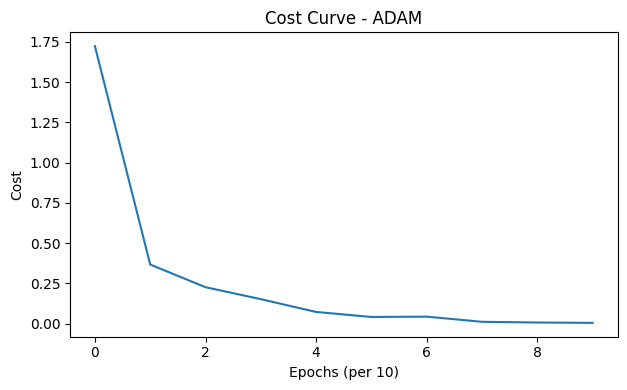


Quick Test Results:
Train Accuracy: 1.0000
Test Accuracy: 0.8200

SAMPLE PREDICTIONS
Sample predictions:
Sample 1: Predicted = Ankle boot, Actual = Ankle boot
Sample 2: Predicted = Pullover, Actual = Pullover
Sample 3: Predicted = Trouser, Actual = Trouser
Sample 4: Predicted = Trouser, Actual = Trouser
Sample 5: Predicted = Shirt, Actual = Shirt


In [ ]:
# ============================================
# QUICK TEST!

# First run debug to check cost
print("="*50)
print("TESTING INITIAL COST")
print("="*50)
test_initial_cost()

print("\n" + "="*50)
print("RUNNING QUICK TEST")
print("="*50)

    # Then run quick test
parameters = quick_test()

    # Optional: Test on a few samples
print("\n" + "="*50)
print("SAMPLE PREDICTIONS")
print("="*50)

# Load test data for demo
(_, _), (X_test, y_test) = fashion_mnist.load_data()
X_test_sample = X_test[:5].reshape(5, -1).T / 255.0

# Get predictions
a3, _ = forward_propagation(X_test_sample, parameters)
predictions = np.argmax(a3, axis=0)

# Fashion-MNIST labels
fashion_labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                      'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Sample predictions:")
for i in range(5):
    print(f"Sample {i+1}: Predicted = {fashion_labels[predictions[i]]}, Actual = {fashion_labels[y_test[i]]}")

# Running Predictions

In [ ]:
# ============================================
# LOAD ALL DATA
# ============================================
print("Loading Fashion-MNIST dataset...")
X_train, Y_train, X_test, Y_test, y_train_raw, y_test_raw, X_train_original, X_test_original = load_and_preprocess_fashion_mnist()

# Define model architecture
layers_dims = [784, 128, 64, 10]

print("\n✅ Data loaded and preprocessed!")

Loading Fashion-MNIST dataset...
Original X_train shape: (60000, 28, 28)
Original y_train shape: (60000,)

Processed X_train shape: (784, 60000)
Processed y_train shape: (10, 60000)
USING FULL DATASET

✅ Data loaded and preprocessed!


In [ ]:
# ============================================
# LOAD $$ SUBSET $$ DATA
# ============================================
print("Loading Fashion-MNIST dataset...")
#X_train, Y_train, X_test, Y_test, y_train_raw, y_test_raw, X_train_original, X_test_original = load_and_preprocess_fashion_mnist_subset()

# Define model architecture
layers_dims = [784, 128, 64, 10]

#print("\n✅ SUBSET loaded and preprocessed!")


Loading Fashion-MNIST dataset...



1. TRAINING WITH GRADIENT DESCENT (Full Batch)
Cost after epoch 0: 2.523339
Cost after epoch 50: 1.746057
Cost after epoch 100: 1.365487
Cost after epoch 150: 1.117965
Cost after epoch 200: 0.980143
Cost after epoch 250: 0.895585
Cost after epoch 300: 0.837847
Cost after epoch 350: 0.795017
Cost after epoch 400: 0.761309
Cost after epoch 450: 0.733643


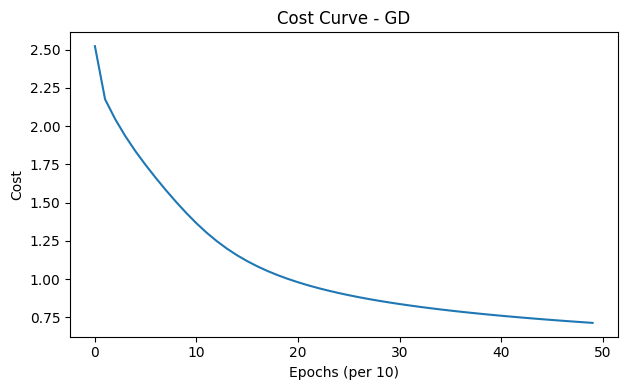


⏱️ Training time: 713.08 seconds

📈 Gradient Descent Results:
   Train Accuracy: 0.7566
   Test Accuracy:  0.7493

🔍 Sample Predictions (Gradient Descent)


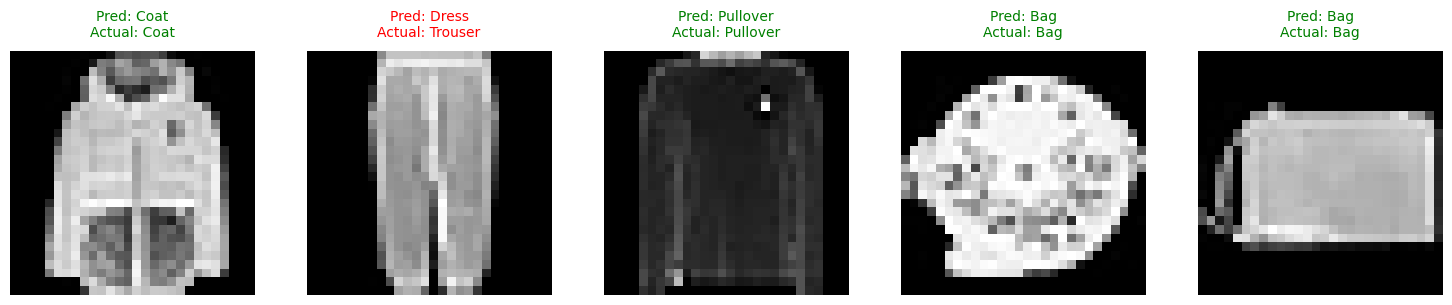


📊 Detailed Predictions:
--------------------------------------------------
❌ Sample 1: Predicted = Shirt           | Actual = Coat           
✅ Sample 2: Predicted = Shirt           | Actual = Shirt          
✅ Sample 3: Predicted = Coat            | Actual = Coat           
✅ Sample 4: Predicted = Coat            | Actual = Coat           
✅ Sample 5: Predicted = Sandal          | Actual = Sandal         


In [ ]:
# ============================================
# 1. TRAINING WITH GRADIENT DESCENT (Full Batch)
# ============================================
print("\n" + "="*50)
print("1. TRAINING WITH GRADIENT DESCENT (Full Batch)")
print("="*50)

start_time = time.time()

parameters_gd = model(
    X_train, Y_train, X_test, Y_test,
    layers_dims=layers_dims,
    optimizer="gd",
    learning_rate=0.01,
    mini_batch_size=X_train.shape[1],  # Full batch
    num_epochs=500, ##MODIFY THIS
    print_cost=True
)

print(f"\n⏱️ Training time: {time.time() - start_time:.2f} seconds")

# Evaluate
train_acc, train_pred = predict(X_train, Y_train, parameters_gd)
test_acc, test_pred = predict(X_test, Y_test, parameters_gd)

print(f"\n📈 Gradient Descent Results:")
print(f"   Train Accuracy: {train_acc:.4f}")
print(f"   Test Accuracy:  {test_acc:.4f}")

# Show sample predictions with images
print("\n" + "="*50)
print("🔍 Sample Predictions (Gradient Descent)")
print("="*50)
show_sample_predictions(parameters_gd, X_test_original, y_test_raw, num_samples=5)


2. TRAINING WITH MINI-BATCH GD + MOMENTUM
Cost after epoch 0: 0.883243
Cost after epoch 50: 0.241059
Cost after epoch 100: 0.165869
Cost after epoch 150: 0.110572
Cost after epoch 200: 0.077671
Cost after epoch 250: 0.049366
Cost after epoch 300: 0.029458
Cost after epoch 350: 0.018531


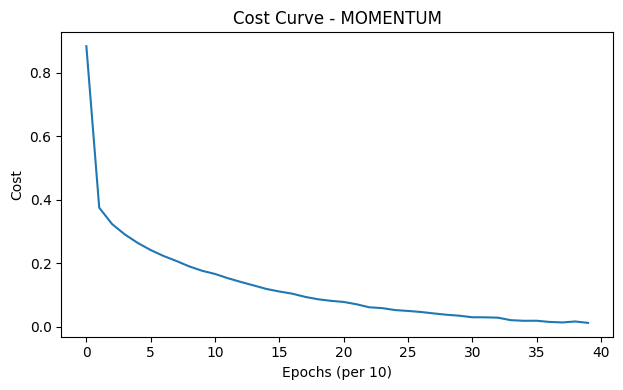


⏱️ Training time: 1398.83 seconds

📈 Momentum Results:
   Train Accuracy: 0.9991
   Test Accuracy:  0.8803

🔍 Sample Predictions (Momentum)


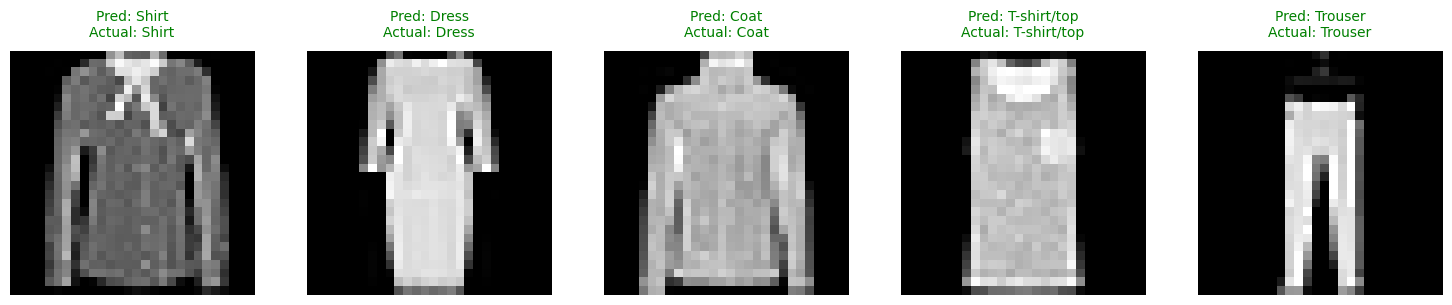


📊 Detailed Predictions:
--------------------------------------------------
❌ Sample 1: Predicted = T-shirt/top     | Actual = Dress          
✅ Sample 2: Predicted = Pullover        | Actual = Pullover       
✅ Sample 3: Predicted = Sneaker         | Actual = Sneaker        
✅ Sample 4: Predicted = Sandal          | Actual = Sandal         
✅ Sample 5: Predicted = Trouser         | Actual = Trouser        


In [ ]:
# ============================================
# 2. TRAINING WITH MINI-BATCH GD + MOMENTUM
# ============================================
print("\n" + "="*50)
print("2. TRAINING WITH MINI-BATCH GD + MOMENTUM")
print("="*50)

start_time = time.time()

parameters_momentum = model(
    X_train, Y_train, X_test, Y_test,
    layers_dims=layers_dims,
    optimizer="momentum",
    learning_rate=0.01,
    mini_batch_size=64,
    beta=0.9,
    num_epochs= 400,
    print_cost=True
)

print(f"\n⏱️ Training time: {time.time() - start_time:.2f} seconds")

# Evaluate
train_acc, _ = predict(X_train, Y_train, parameters_momentum)
test_acc, _ = predict(X_test, Y_test, parameters_momentum)

print(f"\n📈 Momentum Results:")
print(f"   Train Accuracy: {train_acc:.4f}")
print(f"   Test Accuracy:  {test_acc:.4f}")

# Show sample predictions with images
print("\n" + "="*50)
print("🔍 Sample Predictions (Momentum)")
print("="*50)
show_sample_predictions(parameters_momentum, X_test_original, y_test_raw, num_samples=5)


3. TRAINING WITH ADAM OPTIMIZER
Cost after epoch 0: 0.509309
Cost after epoch 50: 0.091658
Cost after epoch 100: 0.045658
Cost after epoch 150: 0.029768
Cost after epoch 200: 0.026871
Cost after epoch 250: 0.019237
Cost after epoch 300: 0.006152
Cost after epoch 350: 0.016876


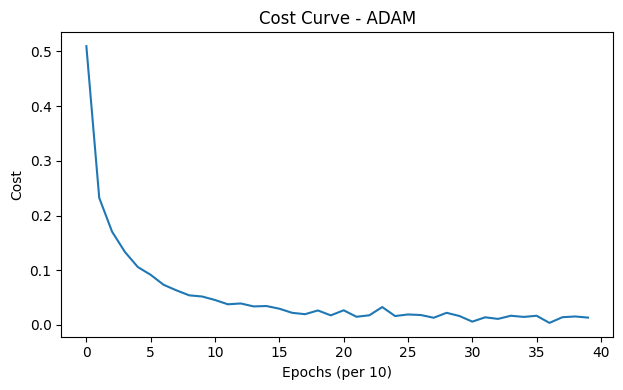


⏱️ Training time: 2193.62 seconds

📈 Adam Results:
   Train Accuracy: 0.9955
   Test Accuracy:  0.8874

🔍 Sample Predictions (Adam)


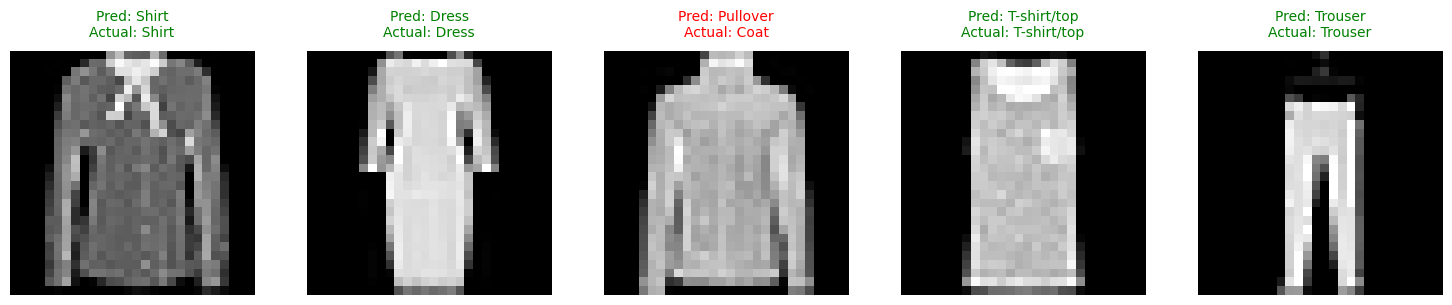


📊 Detailed Predictions:
--------------------------------------------------
❌ Sample 1: Predicted = Pullover        | Actual = Dress          
✅ Sample 2: Predicted = Pullover        | Actual = Pullover       
✅ Sample 3: Predicted = Sneaker         | Actual = Sneaker        
✅ Sample 4: Predicted = Sandal          | Actual = Sandal         
✅ Sample 5: Predicted = Trouser         | Actual = Trouser        


In [ ]:
# ============================================
# 3. TRAINING WITH ADAM OPTIMIZER
# ============================================
print("\n" + "="*50)
print("3. TRAINING WITH ADAM OPTIMIZER")
print("="*50)

start_time = time.time()

parameters_adam = model(
    X_train, Y_train, X_test, Y_test,
    layers_dims=layers_dims,
    optimizer="adam",
    learning_rate=0.001,
    mini_batch_size=64,
    beta1=0.9,
    beta2=0.999,
    num_epochs=400,
    print_cost=True
)

print(f"\n⏱️ Training time: {time.time() - start_time:.2f} seconds")

# Evaluate
train_acc, _ = predict(X_train, Y_train, parameters_adam)
test_acc, _ = predict(X_test, Y_test, parameters_adam)

print(f"\n📈 Adam Results:")
print(f"   Train Accuracy: {train_acc:.4f}")
print(f"   Test Accuracy:  {test_acc:.4f}")

# Show sample predictions with images
print("\n" + "="*50)
print("🔍 Sample Predictions (Adam)")
print("="*50)
show_sample_predictions(parameters_adam, X_test_original, y_test_raw, num_samples=5)


4. TRAINING WITH ADAM + EXPONENTIAL DECAY
Cost after epoch 0: 0.509309
Learning rate after epoch 0: 0.001000
Cost after epoch 50: 0.090884
Learning rate after epoch 50: 0.000976
Cost after epoch 100: 0.045706
Learning rate after epoch 100: 0.000952
Cost after epoch 150: 0.032176
Learning rate after epoch 150: 0.000930
Cost after epoch 200: 0.021471
Learning rate after epoch 200: 0.000909
Cost after epoch 250: 0.018130
Learning rate after epoch 250: 0.000889
Cost after epoch 300: 0.019962
Learning rate after epoch 300: 0.000870
Cost after epoch 350: 0.008553
Learning rate after epoch 350: 0.000851


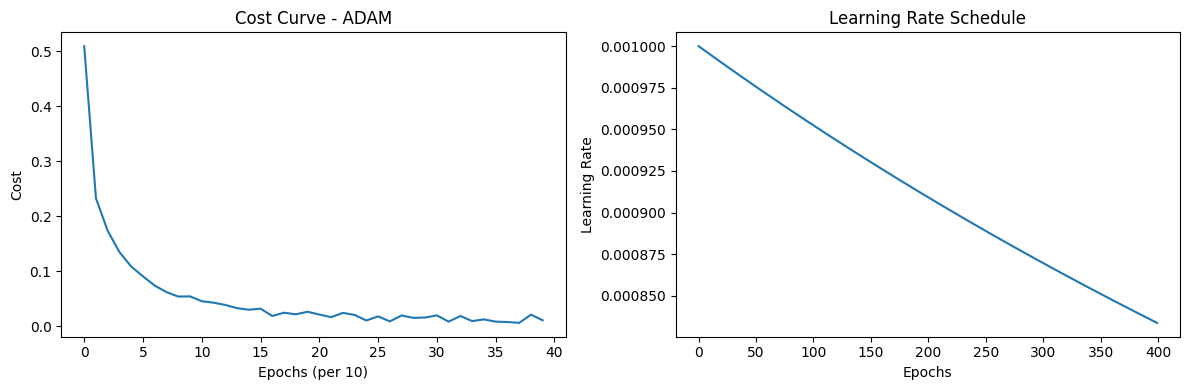


⏱️ Training time: 2306.20 seconds

📈 Adam + Exponential Decay Results:
   Train Accuracy: 0.9931
   Test Accuracy:  0.8899

🔍 Sample Predictions (Adam + Exponential Decay)


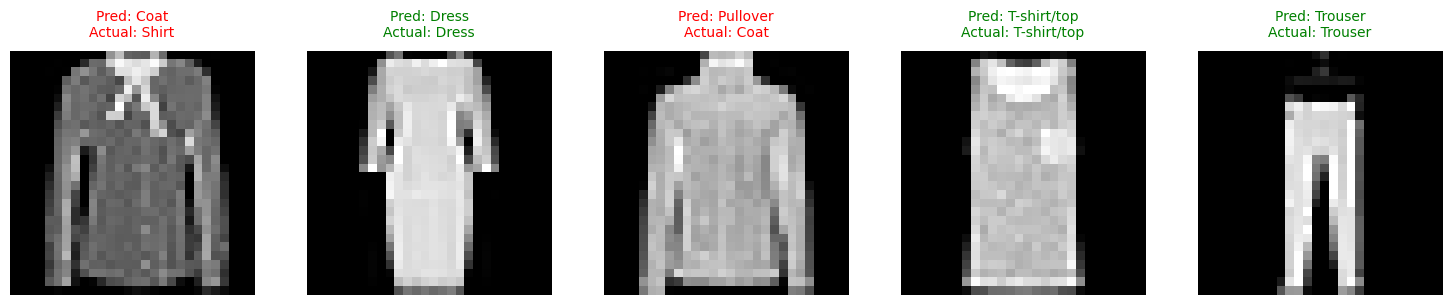


📊 Detailed Predictions:
--------------------------------------------------
✅ Sample 1: Predicted = Dress           | Actual = Dress          
✅ Sample 2: Predicted = Pullover        | Actual = Pullover       
✅ Sample 3: Predicted = Sneaker         | Actual = Sneaker        
✅ Sample 4: Predicted = Sandal          | Actual = Sandal         
✅ Sample 5: Predicted = Trouser         | Actual = Trouser        


In [ ]:
# ============================================
# 4. TRAINING WITH ADAM + EXPONENTIAL DECAY
# ============================================
print("\n" + "="*50)
print("4. TRAINING WITH ADAM + EXPONENTIAL DECAY")
print("="*50)

start_time = time.time()

parameters_adam_decay = model(
    X_train, Y_train, X_test, Y_test,
    layers_dims=layers_dims,
    optimizer="adam",
    learning_rate=0.001,
    mini_batch_size=64,
    num_epochs=400,
    print_cost=True,
    decay=exponential_decay,
    decay_rate={"decay_rate": 0.0005, "time_interval": 1000}
)

print(f"\n⏱️ Training time: {time.time() - start_time:.2f} seconds")

# Evaluate
train_acc, _ = predict(X_train, Y_train, parameters_adam_decay)
test_acc, _ = predict(X_test, Y_test, parameters_adam_decay)

print(f"\n📈 Adam + Exponential Decay Results:")
print(f"   Train Accuracy: {train_acc:.4f}")
print(f"   Test Accuracy:  {test_acc:.4f}")

# Show sample predictions with images
print("\n" + "="*50)
print("🔍 Sample Predictions (Adam + Exponential Decay)")
print("="*50)
show_sample_predictions(parameters_adam_decay, X_test_original, y_test_raw, num_samples=5)


5. TRAINING WITH ADAM + COSINE ANNEALING
Cost after epoch 0: 0.509309
Learning rate after epoch 0: 0.001000
Cost after epoch 50: 0.090300
Learning rate after epoch 50: 0.000998
Cost after epoch 100: 0.044165
Learning rate after epoch 100: 0.000994
Cost after epoch 150: 0.028634
Learning rate after epoch 150: 0.000986
Cost after epoch 200: 0.025003
Learning rate after epoch 200: 0.000976
Cost after epoch 250: 0.011034
Learning rate after epoch 250: 0.000962
Cost after epoch 300: 0.013236
Learning rate after epoch 300: 0.000946
Cost after epoch 350: 0.009409
Learning rate after epoch 350: 0.000926


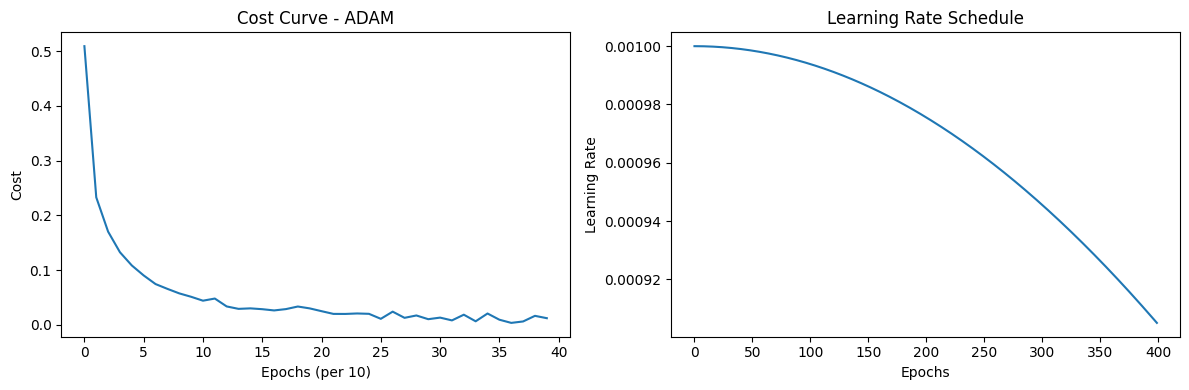


⏱️ Training time: 2177.09 seconds

📈 Adam + Cosine Annealing Results:
   Train Accuracy: 0.9999
   Test Accuracy:  0.8880

🔍 Sample Predictions (Adam + Cosine Annealing)


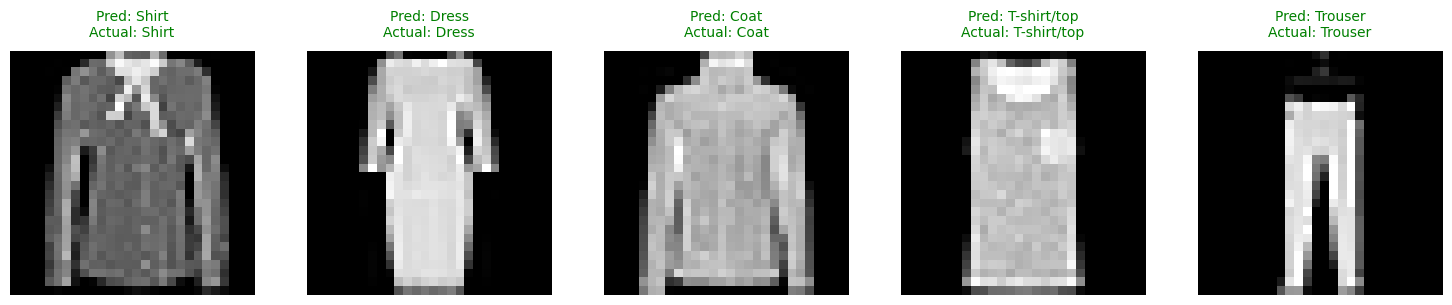


📊 Detailed Predictions:
--------------------------------------------------
❌ Sample 1: Predicted = T-shirt/top     | Actual = Dress          
✅ Sample 2: Predicted = Pullover        | Actual = Pullover       
✅ Sample 3: Predicted = Sneaker         | Actual = Sneaker        
✅ Sample 4: Predicted = Sandal          | Actual = Sandal         
❌ Sample 5: Predicted = Dress           | Actual = Trouser        


In [ ]:
# ============================================
# 5. TRAINING WITH ADAM + COSINE ANNEALING
# ============================================
print("\n" + "="*50)
print("5. TRAINING WITH ADAM + COSINE ANNEALING")
print("="*50)

start_time = time.time()

parameters_cosine = model(
    X_train, Y_train, X_test, Y_test,
    layers_dims=layers_dims,
    optimizer="adam",
    learning_rate=0.001,
    mini_batch_size=64,
    num_epochs= 400,
    print_cost=True,
    decay=cosine_annealing,
    decay_rate={"T_max": 2000, "eta_min": 1e-6}
)

print(f"\n⏱️ Training time: {time.time() - start_time:.2f} seconds")

# Evaluate
train_acc, _ = predict(X_train, Y_train, parameters_cosine)
test_acc, _ = predict(X_test, Y_test, parameters_cosine)

print(f"\n📈 Adam + Cosine Annealing Results:")
print(f"   Train Accuracy: {train_acc:.4f}")
print(f"   Test Accuracy:  {test_acc:.4f}")

# Show sample predictions with images
print("\n" + "="*50)
print("🔍 Sample Predictions (Adam + Cosine Annealing)")
print("="*50)
show_sample_predictions(parameters_cosine, X_test_original, y_test_raw, num_samples=5)


📊 SUMMARY OF RESULTS

Optimizer                    Test Accuracy
--------------------------------------------------
Gradient Descent             0.7493
Momentum                     0.8803
Adam                         0.8874
Adam + Exponential Decay     0.8899
Adam + Cosine Annealing      0.8880


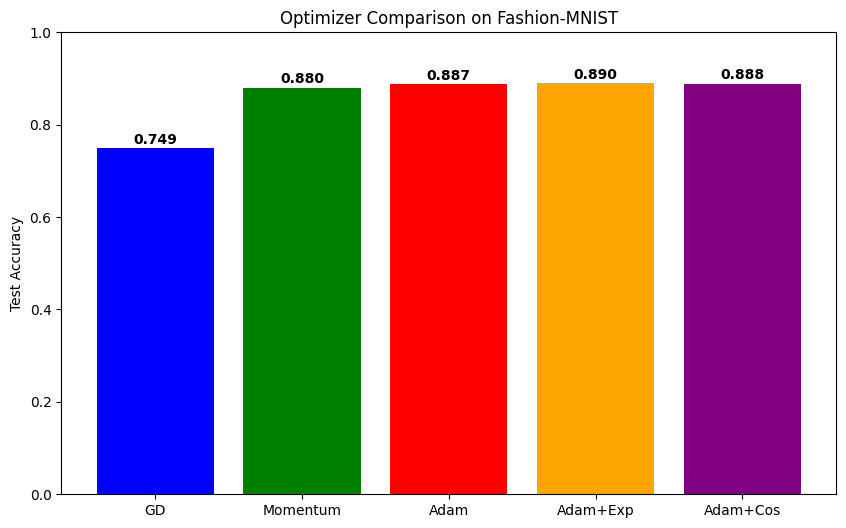

In [ ]:
# ============================================
# FINAL COMPARISON
# ============================================
print("\n" + "="*50)
print("📊 SUMMARY OF RESULTS")
print("="*50)

# Recalculate all accuracies
gd_acc = predict(X_test, Y_test, parameters_gd)[0]
momentum_acc = predict(X_test, Y_test, parameters_momentum)[0]
adam_acc = predict(X_test, Y_test, parameters_adam)[0]
adam_decay_acc = predict(X_test, Y_test, parameters_adam_decay)[0]
cosine_acc = predict(X_test, Y_test, parameters_cosine)[0]

print("\nOptimizer                    Test Accuracy")
print("-"*50)
print(f"Gradient Descent             {gd_acc:.4f}")
print(f"Momentum                     {momentum_acc:.4f}")
print(f"Adam                         {adam_acc:.4f}")
print(f"Adam + Exponential Decay     {adam_decay_acc:.4f}")
print(f"Adam + Cosine Annealing      {cosine_acc:.4f}")

# Create bar chart comparison
plt.figure(figsize=(10, 6))
optimizers = ['GD', 'Momentum', 'Adam', 'Adam+Exp', 'Adam+Cos']
accuracies = [gd_acc, momentum_acc, adam_acc, adam_decay_acc, cosine_acc]
colors = ['blue', 'green', 'red', 'orange', 'purple']

plt.bar(optimizers, accuracies, color=colors)
plt.ylabel('Test Accuracy')
plt.title('Optimizer Comparison on Fashion-MNIST')
plt.ylim(0, 1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.show()

In [ ]:
# @title

# ============================================
# IMPORTS AND SETUP
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
import math
import time

# Set random seed for reproducibility
np.random.seed(42)

# ============================================
# DATA LOADING AND PREPROCESSING
# ============================================
def load_and_preprocess_fashion_mnist():
    """Load and preprocess Fashion-MNIST dataset"""
    # Load data
    (X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


    # Print original shapes
    print(f"Original X_train shape: {X_train.shape}")
    print(f"Original y_train shape: {y_train.shape}")

    #***************************************************
    # Store original images for visualization
    X_train_original = X_train.copy()
    X_test_original = X_test.copy()
    #***************************************************

    # Take subset for faster training (optional - remove for full training)
    # Using 20% of data for quicker testing
    n_train = X_train.shape[0]
    indices = np.random.choice(n_train, n_train // 5, replace=False)
    X_train = X_train[indices]
    y_train = y_train[indices]

    print(f"\nUsing subset: {X_train.shape[0]} training samples")

    # Flatten images: 28x28 = 784 features
    X_train = X_train.reshape(X_train.shape[0], -1).T  # (784, n_samples)
    X_test = X_test.reshape(X_test.shape[0], -1).T    # (784, 10000)

    # Normalize to [0, 1]
    X_train = X_train / 255.0
    X_test = X_test / 255.0

    # One-hot encode labels (10 classes)
    y_train_onehot = np.zeros((10, y_train.shape[0]))
    y_test_onehot = np.zeros((10, y_test.shape[0]))

    for i in range(y_train.shape[0]):
        y_train_onehot[y_train[i], i] = 1
    for i in range(y_test.shape[0]):
        y_test_onehot[y_test[i], i] = 1

    print(f"Processed X_train shape: {X_train.shape}")
    print(f"Processed y_train shape: {y_train_onehot.shape}")

    return X_train, y_train_onehot, X_test, y_test_onehot, y_train, y_test

# ============================================
# ACTIVATION FUNCTIONS
# ============================================
def relu(x):
    """ReLU activation function"""
    return np.maximum(0, x)

def relu_derivative(x):
    """Derivative of ReLU"""
    return (x > 0).astype(float)

def softmax(x):
    """Softmax activation function for multi-class classification"""
    # Subtract max for numerical stability
    shifted_x = x - np.max(x, axis=0, keepdims=True)
    exp_x = np.exp(shifted_x)
    return exp_x / np.sum(exp_x, axis=0, keepdims=True)

# ============================================
# COST FUNCTION (Categorical Cross-Entropy)
# ============================================
def compute_cost(aL, Y):
    """
    Compute categorical cross-entropy cost
    aL: output of last layer (softmax), shape (10, m)
    Y: true labels (one-hot), shape (10, m)
    """
    m = Y.shape[1]
    # Add small epsilon to avoid log(0)
    aL = np.clip(aL, 1e-8, 1 - 1e-8)
    cost = -np.sum(Y * np.log(aL)) / m
    return cost


# ============================================
# FIXED FORWARD PROPAGATION with shape checks
# ============================================
def forward_propagation(X, parameters):
    """
    Forward propagation with shape validation
    """
    # Retrieve parameters
    W1 = parameters["W1"]  # Access parameters
    b1 = parameters["b1"]
    W2 = parameters["W2"]  # Access parameters
    b2 = parameters["b2"]
    W3 = parameters["W3"]  # Access parameters
    b3 = parameters["b3"]

    # Shape validation
    assert X.shape[0] == W1.shape[1], f"X shape {X.shape} doesn't match W1 shape {W1.shape}"

    # Layer 1: Linear -> ReLU
    z1 = np.dot(W1, X) + b1
    a1 = relu(z1)

    # Layer 2: Linear -> ReLU
    z2 = np.dot(W2, a1) + b2
    a2 = relu(z2)

    # Layer 3: Linear -> Softmax
    z3 = np.dot(W3, a2) + b3
    a3 = softmax(z3)

    # Validate softmax output
    assert np.allclose(np.sum(a3, axis=0), 1.0), "Softmax outputs don't sum to 1"

    # Store ONLY what's needed for backprop (ADDED NEW)
    cache = (z1, a1, z2, a2, z3, a3)
    return a3, cache
    #OLD VERSION
   # return a3, (z1, a1, z2, a2, z3, a3)

# ============================================
# FIXED BACKWARD PROPAGATION - Matches new cache format
# ============================================
#Backward propagation uses both cache and parameters

def backward_propagation(X, Y, cache, parameters):
    """
    Backward propagation for multi-class classification
    cache: (z1, a1, z2, a2, z3, a3) from forward_propagation
    parameters: dictionary containing W1, b1, W2, b2, W3, b3
    """
    m = X.shape[1]
    z1, a1, z2, a2, z3, a3 = cache

    # Retrieve weights from parameters
    W1 = parameters["W1"]
    W2 = parameters["W2"]
    W3 = parameters["W3"]

    # Layer 3 gradient (Softmax + Cross-entropy)
    dz3 = a3 - Y  # Simplified gradient for softmax + cross-entropy
    dW3 = np.dot(dz3, a2.T) / m
    db3 = np.sum(dz3, axis=1, keepdims=True) / m

    # Layer 2 gradient
    da2 = np.dot(W3.T, dz3)
    dz2 = np.multiply(da2, np.int64(a2 > 0))  # ReLU derivative
    dW2 = np.dot(dz2, a1.T) / m
    db2 = np.sum(dz2, axis=1, keepdims=True) / m

    # Layer 1 gradient
    da1 = np.dot(W2.T, dz2)
    dz1 = np.multiply(da1, np.int64(a1 > 0))  # ReLU derivative
    dW1 = np.dot(dz1, X.T) / m
    db1 = np.sum(dz1, axis=1, keepdims=True) / m

    gradients = {
        "dW1": dW1, "db1": db1,
        "dW2": dW2, "db2": db2,
        "dW3": dW3, "db3": db3
    }

    return gradients

# ============================================
# INITIALIZATION FUNCTIONS
# ============================================
def initialize_parameters(layer_dims):
    """
    Initialize parameters with He initialization
    """
    parameters = {}
    L = len(layer_dims)

    for l in range(1, L):
        parameters[f"W{l}"] = np.random.randn(layer_dims[l], layer_dims[l-1]) * np.sqrt(2. / layer_dims[l-1])
        parameters[f"b{l}"] = np.zeros((layer_dims[l], 1))

    return parameters

# ============================================
# OPTIMIZERS
# ============================================
def update_parameters_with_gd(parameters, grads, learning_rate):
    """Gradient Descent update"""
    L = len(parameters) // 2
    for l in range(1, L + 1):
        parameters[f"W{l}"] -= learning_rate * grads[f"dW{l}"]
        parameters[f"b{l}"] -= learning_rate * grads[f"db{l}"]
    return parameters

def initialize_velocity(parameters):
    """Initialize velocity for momentum"""
    L = len(parameters) // 2
    v = {}
    for l in range(1, L + 1):
        v[f"dW{l}"] = np.zeros_like(parameters[f"W{l}"])
        v[f"db{l}"] = np.zeros_like(parameters[f"b{l}"])
    return v

def update_parameters_with_momentum(parameters, grads, v, beta, learning_rate):
    """Momentum update"""
    L = len(parameters) // 2
    for l in range(1, L + 1):
        v[f"dW{l}"] = beta * v[f"dW{l}"] + (1 - beta) * grads[f"dW{l}"]
        v[f"db{l}"] = beta * v[f"db{l}"] + (1 - beta) * grads[f"db{l}"]
        parameters[f"W{l}"] -= learning_rate * v[f"dW{l}"]
        parameters[f"b{l}"] -= learning_rate * v[f"db{l}"]
    return parameters, v

def initialize_adam(parameters):
    """Initialize Adam optimizer"""
    L = len(parameters) // 2
    v = {}
    s = {}
    for l in range(1, L + 1):
        v[f"dW{l}"] = np.zeros_like(parameters[f"W{l}"])
        v[f"db{l}"] = np.zeros_like(parameters[f"b{l}"])
        s[f"dW{l}"] = np.zeros_like(parameters[f"W{l}"])
        s[f"db{l}"] = np.zeros_like(parameters[f"b{l}"])
    return v, s

def update_parameters_with_adam(parameters, grads, v, s, t, learning_rate, beta1=0.9, beta2=0.999, epsilon=1e-8):
    """Adam optimizer update"""
    L = len(parameters) // 2

    for l in range(1, L + 1):
        # Update biased first moment estimate
        v[f"dW{l}"] = beta1 * v[f"dW{l}"] + (1 - beta1) * grads[f"dW{l}"]
        v[f"db{l}"] = beta1 * v[f"db{l}"] + (1 - beta1) * grads[f"db{l}"]

        # Update biased second raw moment estimate
        s[f"dW{l}"] = beta2 * s[f"dW{l}"] + (1 - beta2) * (grads[f"dW{l}"] ** 2)
        s[f"db{l}"] = beta2 * s[f"db{l}"] + (1 - beta2) * (grads[f"db{l}"] ** 2)

        # Compute bias-corrected estimates
        v_corrected_dW = v[f"dW{l}"] / (1 - beta1 ** t)
        v_corrected_db = v[f"db{l}"] / (1 - beta1 ** t)
        s_corrected_dW = s[f"dW{l}"] / (1 - beta2 ** t)
        s_corrected_db = s[f"db{l}"] / (1 - beta2 ** t)

        # Update parameters
        parameters[f"W{l}"] -= learning_rate * v_corrected_dW / (np.sqrt(s_corrected_dW) + epsilon)
        parameters[f"b{l}"] -= learning_rate * v_corrected_db / (np.sqrt(s_corrected_db) + epsilon)

    return parameters, v, s

# ============================================
# MINI-BATCH GENERATION
# ============================================
def random_mini_batches(X, Y, mini_batch_size=64, seed=0):
    """Create random mini-batches"""
    np.random.seed(seed)
    m = X.shape[1]
    mini_batches = []

    # Shuffle
    permutation = np.random.permutation(m)
    shuffled_X = X[:, permutation]
    shuffled_Y = Y[:, permutation]

    # Partition
    num_complete_minibatches = math.floor(m / mini_batch_size)
    for k in range(num_complete_minibatches):
        mini_batch_X = shuffled_X[:, k * mini_batch_size:(k + 1) * mini_batch_size]
        mini_batch_Y = shuffled_Y[:, k * mini_batch_size:(k + 1) * mini_batch_size]
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)

    # Handle last mini-batch
    if m % mini_batch_size != 0:
        mini_batch_X = shuffled_X[:, num_complete_minibatches * mini_batch_size:]
        mini_batch_Y = shuffled_Y[:, num_complete_minibatches * mini_batch_size:]
        mini_batch = (mini_batch_X, mini_batch_Y)
        mini_batches.append(mini_batch)

    return mini_batches

# ============================================
# PREDICTION FUNCTION
# ============================================
def predict(X, Y, parameters):
    """Make predictions and calculate accuracy"""
    a3, _ = forward_propagation(X, parameters)
    predictions = np.argmax(a3, axis=0)
    true_labels = np.argmax(Y, axis=0)
    accuracy = np.mean(predictions == true_labels)
    return accuracy, predictions

# ============================================
# FIXED MODEL FUNCTION - Passes parameters to backward_propagation
# ============================================
def model(X_train, Y_train, X_test, Y_test, layers_dims, optimizer="gd",
          learning_rate=0.01, mini_batch_size=64, beta=0.9, beta1=0.9,
          beta2=0.999, epsilon=1e-8, num_epochs=5000, print_cost=True,
          decay=None, decay_rate=None):
    """
    Main model training function
    """
    # Initialize parameters
    parameters = initialize_parameters(layers_dims)

    # Initialize optimizer
    if optimizer == "momentum":
        v = initialize_velocity(parameters)
    elif optimizer == "adam":
        v, s = initialize_adam(parameters)
        t = 0

    costs = []
    lr_rates = []
    learning_rate0 = learning_rate

    # Training loop
    for i in range(num_epochs):
        # Create mini-batches
        if mini_batch_size == X_train.shape[1]:
            # Full batch
            mini_batches = [(X_train, Y_train)]
        else:
            mini_batches = random_mini_batches(X_train, Y_train, mini_batch_size, seed=i)

        cost_total = 0

        for minibatch in mini_batches:
            minibatch_X, minibatch_Y = minibatch

            # Forward propagation
            a3, cache = forward_propagation(minibatch_X, parameters)

            # Compute cost
            cost_total += compute_cost(a3, minibatch_Y) * minibatch_X.shape[1]

            # Backward propagation - NOW PASS parameters
            grads = backward_propagation(minibatch_X, minibatch_Y, cache, parameters)

            # Update parameters
            if optimizer == "gd":
                parameters = update_parameters_with_gd(parameters, grads, learning_rate)
            elif optimizer == "momentum":
                parameters, v = update_parameters_with_momentum(parameters, grads, v, beta, learning_rate)
            elif optimizer == "adam":
                t += 1
                parameters, v, s = update_parameters_with_adam(parameters, grads, v, s, t, learning_rate, beta1, beta2, epsilon)

        cost_avg = cost_total / X_train.shape[1]

        # Update learning rate if decay is provided
        if decay:
            if decay_rate:
                learning_rate = decay(learning_rate0, i, **decay_rate)
            else:
                learning_rate = decay(learning_rate0, i)
            lr_rates.append(learning_rate)

        # Print cost
        if print_cost and i % 50 == 0:
            print(f"Cost after epoch {i}: {cost_avg:.6f}")
            if decay:
                print(f"Learning rate after epoch {i}: {learning_rate:.6f}")

        if i % 10 == 0:
            costs.append(cost_avg)

    # Plot cost
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(costs)
    plt.ylabel('Cost')
    plt.xlabel('Epochs (per 10)')
    plt.title(f'Cost Curve - {optimizer.upper()}')

    if decay and lr_rates:
        plt.subplot(1, 2, 2)
        plt.plot(lr_rates)
        plt.xlabel('Epochs')
        plt.ylabel('Learning Rate')
        plt.title('Learning Rate Schedule')

    plt.tight_layout()
    plt.show()

    return parameters

# ============================================
# LEARNING RATE SCHEDULERS
# ============================================
def exponential_decay(learning_rate0, epoch_num, decay_rate=0.1, time_interval=10):
    """Exponential learning rate decay"""
    return learning_rate0 / (1 + decay_rate * epoch_num)

def step_decay(learning_rate0, epoch_num, drop_rate=0.5, epochs_drop=1000):
    """Step learning rate decay"""
    return learning_rate0 * (drop_rate ** (epoch_num // epochs_drop))

def cosine_annealing(learning_rate0, epoch_num, T_max, eta_min=0):
    """Cosine annealing learning rate schedule"""
    return eta_min + (learning_rate0 - eta_min) * 0.5 * (1 + math.cos(math.pi * epoch_num / T_max))

# ============================================
# MAIN EXECUTION
# ============================================
if __name__ == "__main__":
    # Load and preprocess data
    print("Loading Fashion-MNIST dataset...")
    X_train, Y_train, X_test, Y_test, y_train_raw, y_test_raw = load_and_preprocess_fashion_mnist()

    # Define model architecture (784 input, 2 hidden layers, 10 output)
    layers_dims = [784, 128, 64, 10]

    ###########
    ## TRAINING WITH GRADIENT DESCENT (Full Batch)
    ############
    print("\n" + "="*50)
    print("1. TRAINING WITH GRADIENT DESCENT (Full Batch)")
    print("="*50)

    start_time = time.time()
    parameters_gd = model(
        X_train, Y_train, X_test, Y_test,
        layers_dims=layers_dims,
        optimizer="gd",
        learning_rate=0.1,  # Increased learning rate
        mini_batch_size=X_train.shape[1],  # Full batch
        num_epochs=200,  # Reduced epochs
        print_cost=True
    )
    print(f"Time taken: {time.time() - start_time:.2f} seconds")

    # Evaluate
    train_acc, _ = predict(X_train, Y_train, parameters_gd)
    test_acc, _ = predict(X_test, Y_test, parameters_gd)
    print(f"\nGradient Descent Results:")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")


    # Show sample predictions with images
    print("\n" + "="*50)
    print("🔍 Sample Predictions (GD FULL BATCH)")
    print("="*50)
    show_sample_predictions(parameters_gd, X_test_original, y_test_raw, num_samples=5)


    ###########
    ## "2. TRAINING WITH MINI-BATCH GD + MOMENTUM"
    ############
    print("\n" + "="*50)
    print("2. TRAINING WITH MINI-BATCH GD + MOMENTUM")
    print("="*50)

    start_time = time.time()
    parameters_momentum = model(
        X_train, Y_train, X_test, Y_test,
        layers_dims=layers_dims,
        optimizer="momentum",
        learning_rate=0.01,
        mini_batch_size=64,
        beta=0.9,
        num_epochs=200,
        print_cost=True
    )
    print(f"Time taken: {time.time() - start_time:.2f} seconds")

    train_acc, _ = predict(X_train, Y_train, parameters_momentum)
    test_acc, _ = predict(X_test, Y_test, parameters_momentum)
    print(f"\nMomentum Results:")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")


    # Show sample predictions with images
    print("\n" + "="*50)
    print("🔍 Sample Predictions (MOMENTUM-MiniBatch)")
    print("="*50)
    show_sample_predictions(parameters_momentum, X_test_original, y_test_raw, num_samples=5)

     ###########
    ## "3. TRAINING WITH ADAM OPTIMIZER"
    ############
    print("\n" + "="*50)
    print("3. TRAINING WITH ADAM OPTIMIZER")
    print("="*50)

    start_time = time.time()
    parameters_adam = model(
        X_train, Y_train, X_test, Y_test,
        layers_dims=layers_dims,
        optimizer="adam",
        learning_rate=0.001,
        mini_batch_size=64,
        beta1=0.9,
        beta2=0.999,
        num_epochs=200,
        print_cost=True
    )
    print(f"Time taken: {time.time() - start_time:.2f} seconds")

    train_acc, _ = predict(X_train, Y_train, parameters_adam)
    test_acc, _ = predict(X_test, Y_test, parameters_adam)
    print(f"\nAdam Results:")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    # Show sample predictions with images
    print("\n" + "="*50)
    print("🔍 Sample Predictions (ADAM-MiniBatch)")
    print("="*50)
    show_sample_predictions(parameters_momentum, X_test_original, y_test_raw, num_samples=5)


    ##===========================
    # Final comparison
    ##===========================

    print("\n" + "="*50)
    print("SUMMARY OF RESULTS")
    print("="*50)
    print("Optimizer          Train Acc    Test Acc")
    print("-"*50)
    print(f"Gradient Descent   {predict(X_train, Y_train, parameters_gd)[0]:.4f}        {predict(X_test, Y_test, parameters_gd)[0]:.4f}")
    print(f"Momentum           {predict(X_train, Y_train, parameters_momentum)[0]:.4f}        {predict(X_test, Y_test, parameters_momentum)[0]:.4f}")
    print(f"Adam               {predict(X_train, Y_train, parameters_adam)[0]:.4f}        {predict(X_test, Y_test, parameters_adam)[0]:.4f}")